In [1]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import os.path
import cv2
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torchvision.models as models

In [2]:
train_data = 'data/train'
test_data = 'data/test'

In [3]:
def load_data(data_dir):
    image_paths =[]
    labels = []
    for folder_name in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder_name)
        if os.path.isdir(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith('.jpeg'):
                    image_paths.append(os.path.join(folder_path, file_name))
                    labels.append(1 if folder_name == 'PNEUMONIA' else 0)
                    
    return image_paths, labels



In [4]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
    
])

In [5]:
class Data(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
        
    
    

In [6]:
train_paths, train_labels = load_data(train_data)
test_paths, test_labels = load_data(test_data)
train_paths, val_paths, train_labels, val_labels = train_test_split(train_paths,train_labels, test_size = 0.2, random_state = 42)

In [7]:
train_dataset = Data(train_paths, train_labels, transform = transform)
val_dataset = Data(val_paths, val_labels, transform = transform)
test_dataset = Data(test_paths, test_labels, transform = transform)

In [8]:
train_loader = DataLoader(train_dataset, batch_size = 100, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 100, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 100, shuffle = False)

In [9]:
class XQCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(pretrained = True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)
        for param in self.model.parameters():
            param.requires_grad = False
        self.model.fc.weight.requires_grad = True
        self.model.fc.bias.requires_grad = True


    def forward(self, x):
        return self.model(x)
    
model = XQCNN()

d:\python\Cnn\x-quang\library\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\python\Cnn\x-quang\library\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
for param in model.model.parameters():
    param.requires_grad = False

# Chỉ mở gradient cho lớp fc cuối (classifier)
for param in model.model.fc.parameters():
    param.requires_grad = True

In [11]:
entro = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.model.fc.parameters(), lr = 1e-3)

In [12]:
#training_loop 
epochs = 5
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for image, label in train_loader:
        optimizer.zero_grad()
        output = model(image)
        preds = torch.argmax(output, 1)
        loss = entro(output, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (preds == label).sum().item()
        train_total += label.size(0)
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total
    
    
    model.eval()
    with torch.no_grad():
        val_loss = 0
        val_correct = 0
        val_total = 0
        for image, label in val_loader:
            output = model(image)
            preds = torch.argmax(output, 1)
            
            loss = entro(output, label)
            val_loss += loss.item()
            val_correct += (preds == label).sum().item()
            val_total += label.size(0)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / val_total
        
            
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(avg_train_acc)
    val_acc_history.append(avg_val_acc)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Train Acc: {avg_train_acc:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {avg_val_acc:.4f}")

Epoch 1/5 - Train Loss: 0.4033 - Train Acc: 0.8275 - Val Loss: 0.6001 - Val Acc: 0.7307
Epoch 2/5 - Train Loss: 0.2171 - Train Acc: 0.9192 - Val Loss: 0.1967 - Val Acc: 0.9245
Epoch 3/5 - Train Loss: 0.1861 - Train Acc: 0.9264 - Val Loss: 0.1837 - Val Acc: 0.9179
Epoch 4/5 - Train Loss: 0.1688 - Train Acc: 0.9357 - Val Loss: 0.1613 - Val Acc: 0.9331
Epoch 5/5 - Train Loss: 0.1504 - Train Acc: 0.9436 - Val Loss: 0.1521 - Val Acc: 0.9341


In [ ]:
#test, ve do thi, heatmap, confusion_matrix, classification_report, 

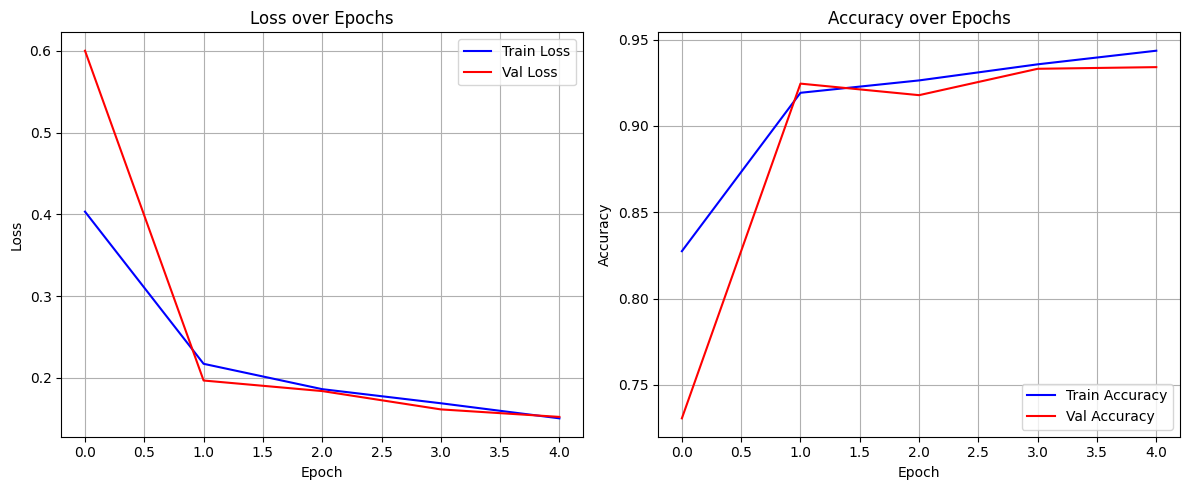

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Val Loss', color='red')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Accuracy', color='blue')
plt.plot(val_acc_history, label='Val Accuracy', color='red')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

In [ ]:
predict_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((150, 150)),       
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

def predict_image(image_path):
    model.eval()
    with torch.no_grad():
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = predict_transform(img).unsqueeze(0)  
            
        output = model(img_tensor)
        prob = torch.softmax(output, dim=1)[0]
        pred = torch.argmax(prob).item()
        
        confidence = prob[pred].item() * 100
        
        result = "PNEUMONIA (BỆNH VIÊM PHỔI)" if pred == 1 else "NORMAL (BÌNH THƯỜNG)"
        color = "red" if pred == 1 else "green"
        
        return result, confidence, color

#cua so

def upload_and_predict():
    file_path = filedialog.askopenfilename(
        title="Chọn ảnh X-quang phổi",
        filetypes=[("Image files", "*.jpeg *.jpg *.png")]
    )
    
    if not file_path:
        return
    #
    result_text, confidence, color = predict_image(file_path)
    #truy cap vao image
    
    img = Image.open(file_path)
    img = img.resize((300, 300))
    img_tk = ImageTk.PhotoImage(img)
    
    #    #cap nhat anh len giao dien

    img_label.config(image=img_tk)
    img_label.image = img_tk 
    
    result_label.config(text=result_text, fg=color)
    confidence_label.config(text=f"Độ tin cậy: {confidence:.2f}%")
#tao cua so
root = tk.Tk()
root.title("Dự đoán bệnh viêm phổi từ ảnh X-quang")
root.geometry("600x700")
    #khoi tao giao dien

tk.Label(root, text="HỆ THỐNG DỰ ĐOÁN VIÊM PHỔI", font=("Arial", 16, "bold")).pack(pady=10)

upload_btn = tk.Button(root, text="📤 Tải ảnh X-quang lên", font=("Arial", 12), 
                       command=upload_and_predict, height=2, width=30)
upload_btn.pack(pady=20)

img_label = tk.Label(root)
img_label.pack(pady=10)

result_label = tk.Label(root, text="Kết quả sẽ hiện ở đây", font=("Arial", 14, "bold"))
result_label.pack(pady=10)

confidence_label = tk.Label(root, text="", font=("Arial", 12))
confidence_label.pack()

tk.Label(root, text="Lưu ý: Model đã được train trên dữ liệu thực tế", fg="gray").pack(pady=20)

root.mainloop()